# Исследование данных

Цель EDA — понять, какие признаки связаны с отменой и что стоит передать модели. Здесь ищем зависимости, но не называем их причинами.

## 1. Загрузка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

df = pd.read_parquet(ROOT / "data/interim/hotel_bookings_clean.parquet")
sns.set_theme(style="whitegrid")

df.shape

(119390, 27)

## 2. Целевая переменная

In [2]:
target_stats = df["is_canceled"].value_counts().sort_index().to_frame("bookings")
target_stats["share"] = target_stats["bookings"] / len(df)
target_stats

,bookings,share
is_canceled,,
0,75166,0.629584
1,44224,0.370416


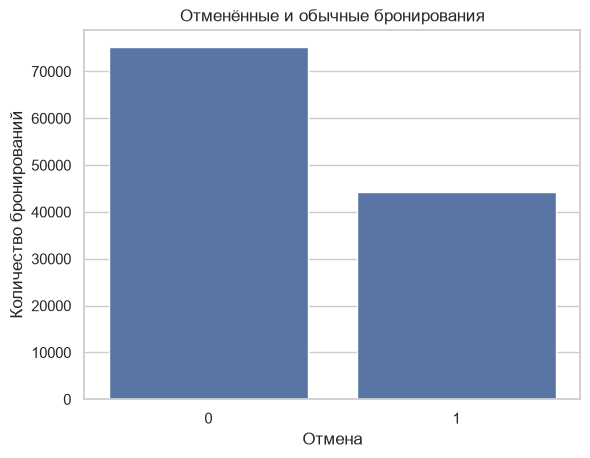

In [3]:
sns.countplot(data=df, x="is_canceled")
plt.title("Отменённые и обычные бронирования")
plt.xlabel("Отмена")
plt.ylabel("Количество бронирований")
plt.show()

Отменённых бронирований меньше, чем обычных, но редким этот класс назвать нельзя. Одной accuracy здесь будет мало, поэтому модели будем сравнивать по PR-AUC и ROC-AUC, а рабочий порог — по Precision и Recall.

## 3. Категориальные признаки

In [4]:
def cancellation_stats(column):
    return (
        df.groupby(column, observed=True)["is_canceled"]
        .agg(bookings="size", cancellation_rate="mean")
        .sort_values("bookings", ascending=False)
    )


for column in ["hotel", "deposit_type", "market_segment", "customer_type"]:
    print(f"\n{column}")
    display(cancellation_stats(column).round(3))


hotel


,bookings,cancellation_rate
hotel,,
City Hotel,79330,0.417
Resort Hotel,40060,0.278



deposit_type


,bookings,cancellation_rate
deposit_type,,
No Deposit,104641,0.284
Non Refund,14587,0.994
Refundable,162,0.222



market_segment


,bookings,cancellation_rate
market_segment,,
Online TA,56477,0.367
Offline TA/TO,24219,0.343
Groups,19811,0.611
Direct,12606,0.153
Corporate,5295,0.187
Complementary,743,0.131
Aviation,237,0.219
Undefined,2,1.000



customer_type


,bookings,cancellation_rate
customer_type,,
Transient,89613,0.407
Transient-Party,25124,0.254
Contract,4076,0.310
Group,577,0.102


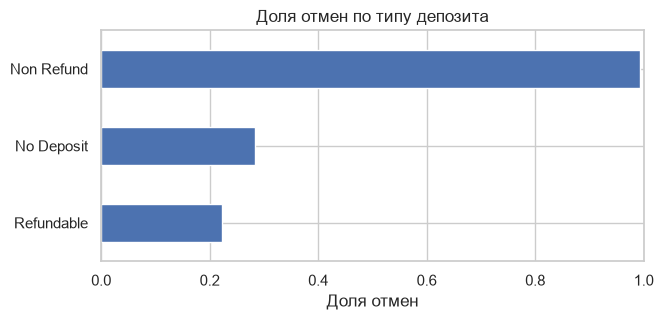

In [5]:
deposit_stats = cancellation_stats("deposit_type").sort_values("cancellation_rate")
deposit_stats["cancellation_rate"].plot(kind="barh", figsize=(7, 3))
plt.title("Доля отмен по типу депозита")
plt.xlabel("Доля отмен")
plt.ylabel("")
plt.xlim(0, 1)
plt.show()

Самый сильный сигнал даёт `deposit_type`: почти все бронирования `Non Refund` в этом датасете были отменены. Разница также видна между типами отелей и сегментами рынка.

У редких категорий высокий процент может получиться случайно, поэтому процент без числа бронирований мало о чём говорит.

## 4. Lead time

In [6]:
lead_time_labels = ["0–7", "8–30", "31–90", "91–180", "181–365", "365+"]
lead_time_group = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=lead_time_labels,
)

lead_time_stats = (
    df.groupby(lead_time_group, observed=True)["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
)
lead_time_stats

,bookings,cancellation_rate
lead_time,,
0–7,19746,0.096323
8–30,18960,0.278639
31–90,29553,0.376984
91–180,26439,0.447105
181–365,21544,0.554540
365+,3148,0.676620


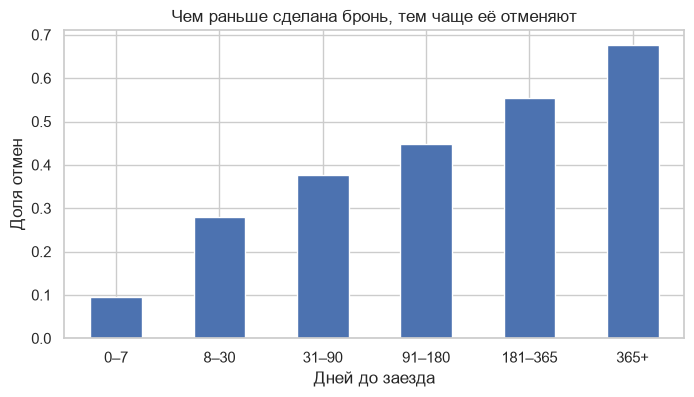

In [7]:
lead_time_stats["cancellation_rate"].plot(kind="bar", figsize=(8, 4))
plt.title("Чем раньше сделана бронь, тем чаще её отменяют")
plt.xlabel("Дней до заезда")
plt.ylabel("Доля отмен")
plt.xticks(rotation=0)
plt.show()

Зависимость почти монотонная: у бронирований за неделю отмен около 10%, а при сроке больше года — уже около 68%. Похоже, `lead_time` будет одним из самых полезных признаков.

## 5. Стоимость и размер бронирования

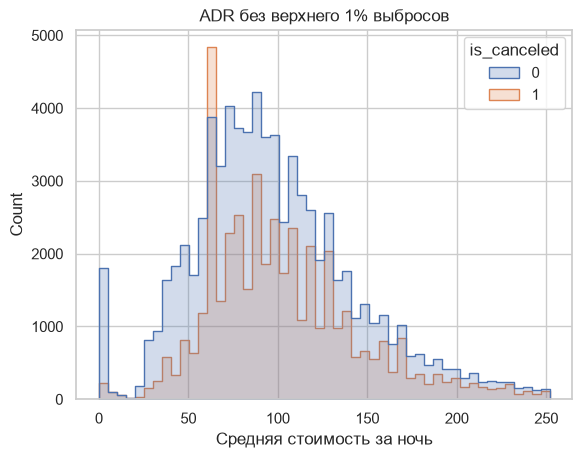

In [8]:
adr_limit = df["adr"].quantile(0.99)

sns.histplot(
    data=df[df["adr"].between(0, adr_limit)],
    x="adr",
    hue="is_canceled",
    bins=50,
    element="step",
)
plt.title("ADR без верхнего 1% выбросов")
plt.xlabel("Средняя стоимость за ночь")
plt.show()

In [9]:
total_guests = df["adults"] + df["children"].fillna(0) + df["babies"]
total_nights = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

pd.DataFrame({
    "not_canceled": [
        df.loc[df["is_canceled"] == 0, "adr"].median(),
        total_guests[df["is_canceled"] == 0].median(),
        total_nights[df["is_canceled"] == 0].median(),
    ],
    "canceled": [
        df.loc[df["is_canceled"] == 1, "adr"].median(),
        total_guests[df["is_canceled"] == 1].median(),
        total_nights[df["is_canceled"] == 1].median(),
    ],
}, index=["adr_median", "guests_median", "nights_median"])

,not_canceled,canceled
adr_median,92.5,96.2
guests_median,2.0,2.0
nights_median,3.0,3.0


ADR сильно скошен вправо, но одного такого графика недостаточно, чтобы выбрасывать дорогие бронирования.

Общее число гостей и ночей по отдельности слабо разделяет классы, но понятнее описывает размер брони. Поэтому `total_guests` и `total_nights` имеет смысл добавить к исходным признакам.

## 6. История клиента и страна

In [10]:
history_stats = (
    df.assign(has_previous_cancellation=df["previous_cancellations"].gt(0))
    .groupby("has_previous_cancellation")["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
)

country_group = np.select(
    [df["country"].eq("PRT"), df["country"].eq("Unknown")],
    ["Domestic", "Unknown"],
    default="Foreign",
)
country_stats = (
    df.assign(country_group=country_group)
    .groupby("country_group")["is_canceled"]
    .agg(bookings="size", cancellation_rate="mean")
)

display(history_stats.round(3))
display(country_stats.round(3))

,bookings,cancellation_rate
has_previous_cancellation,,
False,112906,0.339
True,6484,0.916


,bookings,cancellation_rate
country_group,,
Domestic,48590,0.566
Foreign,70312,0.237
Unknown,488,0.137


В общей выборке прошлая отмена выглядит сильным сигналом. Здесь пригодится простой бинарный признак — была ли у клиента хотя бы одна отмена раньше.

Брони из Португалии отменяются чаще иностранных, хотя причина по этой таблице не видна. Поэтому полезно сохранить и исходную страну, и более общую группу `Domestic / Foreign / Unknown`.

## 7. Изменение доли отмен во времени

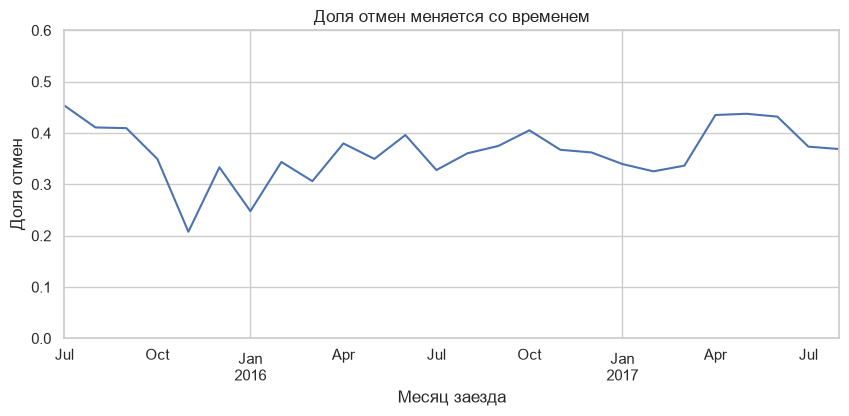

In [11]:
month_number = {
    month: number
    for number, month in enumerate(
        [
            "January", "February", "March", "April", "May", "June",
            "July", "August", "September", "October", "November", "December",
        ],
        start=1,
    )
}

arrival_date = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_number),
    "day": df["arrival_date_day_of_month"],
})

monthly_target = (
    df.assign(arrival_date=arrival_date)
    .set_index("arrival_date")["is_canceled"]
    .resample("MS")
    .mean()
)

monthly_target.plot(figsize=(10, 4))
plt.title("Доля отмен меняется со временем")
plt.xlabel("Месяц заезда")
plt.ylabel("Доля отмен")
plt.ylim(0, 0.6)
plt.show()

Доля отмен заметно меняется со временем. Случайный split смешал бы разные периоды и дал слишком оптимистичную оценку, поэтому дальше данные будут идти строго из прошлого в будущее.

## Итог EDA

Больше всего выделяются `lead_time`, `deposit_type`, история отмен, страна, тип отеля и сегмент рынка.

Сложный feature engineering здесь не нужен. Достаточно нескольких понятных признаков: общего числа гостей и ночей, наличия агента или компании, группы страны и факта прошлой отмены.